# Keras TF 2.0 - Code Along Classification Project

Let's explore a classification task with Keras API for TF 2.0

## The Data

### Breast cancer wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

    :Number of Instances: 569

    :Number of Attributes: 30 numeric, predictive attributes and the class

    :Attribute Information:
        - radius (mean of distances from center to points on the perimeter)
        - texture (standard deviation of gray-scale values)
        - perimeter
        - area
        - smoothness (local variation in radius lengths)
        - compactness (perimeter^2 / area - 1.0)
        - concavity (severity of concave portions of the contour)
        - concave points (number of concave portions of the contour)
        - symmetry 
        - fractal dimension ("coastline approximation" - 1)

        The mean, standard error, and "worst" or largest (mean of the three
        largest values) of these features were computed for each image,
        resulting in 30 features.  For instance, field 3 is Mean Radius, field
        13 is Radius SE, field 23 is Worst Radius.

        - class:
                - WDBC-Malignant
                - WDBC-Benign

    :Summary Statistics:

    ===================================== ====== ======
                                           Min    Max
    ===================================== ====== ======
    radius (mean):                        6.981  28.11
    texture (mean):                       9.71   39.28
    perimeter (mean):                     43.79  188.5
    area (mean):                          143.5  2501.0
    smoothness (mean):                    0.053  0.163
    compactness (mean):                   0.019  0.345
    concavity (mean):                     0.0    0.427
    concave points (mean):                0.0    0.201
    symmetry (mean):                      0.106  0.304
    fractal dimension (mean):             0.05   0.097
    radius (standard error):              0.112  2.873
    texture (standard error):             0.36   4.885
    perimeter (standard error):           0.757  21.98
    area (standard error):                6.802  542.2
    smoothness (standard error):          0.002  0.031
    compactness (standard error):         0.002  0.135
    concavity (standard error):           0.0    0.396
    concave points (standard error):      0.0    0.053
    symmetry (standard error):            0.008  0.079
    fractal dimension (standard error):   0.001  0.03
    radius (worst):                       7.93   36.04
    texture (worst):                      12.02  49.54
    perimeter (worst):                    50.41  251.2
    area (worst):                         185.2  4254.0
    smoothness (worst):                   0.071  0.223
    compactness (worst):                  0.027  1.058
    concavity (worst):                    0.0    1.252
    concave points (worst):               0.0    0.291
    symmetry (worst):                     0.156  0.664
    fractal dimension (worst):            0.055  0.208
    ===================================== ====== ======

    :Missing Attribute Values: None

    :Class Distribution: 212 - Malignant, 357 - Benign

    :Creator:  Dr. William H. Wolberg, W. Nick Street, Olvi L. Mangasarian

    :Donor: Nick Street

    :Date: November, 1995

This is a copy of UCI ML Breast Cancer Wisconsin (Diagnostic) datasets.
https://goo.gl/U2Uwz2

Features are computed from a digitized image of a fine needle
aspirate (FNA) of a breast mass.  They describe
characteristics of the cell nuclei present in the image.

Separating plane described above was obtained using
Multisurface Method-Tree (MSM-T) [K. P. Bennett, "Decision Tree
Construction Via Linear Programming." Proceedings of the 4th
Midwest Artificial Intelligence and Cognitive Science Society,
pp. 97-101, 1992], a classification method which uses linear
programming to construct a decision tree.  Relevant features
were selected using an exhaustive search in the space of 1-4
features and 1-3 separating planes.

The actual linear program used to obtain the separating plane
in the 3-dimensional space is that described in:
[K. P. Bennett and O. L. Mangasarian: "Robust Linear
Programming Discrimination of Two Linearly Inseparable Sets",
Optimization Methods and Software 1, 1992, 23-34].

This database is also available through the UW CS ftp server:

ftp ftp.cs.wisc.edu
cd math-prog/cpo-dataset/machine-learn/WDBC/

.. topic:: References

   - W.N. Street, W.H. Wolberg and O.L. Mangasarian. Nuclear feature extraction 
     for breast tumor diagnosis. IS&T/SPIE 1993 International Symposium on 
     Electronic Imaging: Science and Technology, volume 1905, pages 861-870,
     San Jose, CA, 1993.
   - O.L. Mangasarian, W.N. Street and W.H. Wolberg. Breast cancer diagnosis and 
     prognosis via linear programming. Operations Research, 43(4), pages 570-577, 
     July-August 1995.
   - W.H. Wolberg, W.N. Street, and O.L. Mangasarian. Machine learning techniques
     to diagnose breast cancer from fine-needle aspirates. Cancer Letters 77 (1994) 
     163-171.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../../Resources/TF_2_Notebooks_and_Data/DATA/cancer_classification.csv")
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,benign_0__mal_1
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [4]:
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
mean texture,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
mean area,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
mean compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
mean concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
mean concave points,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
mean symmetry,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


# EDA

In [5]:
df.corr()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,benign_0__mal_1
mean radius,1.000000,0.323782,0.997855,0.987357,0.170581,0.506124,0.676764,0.822529,0.147741,-0.311631,...,0.297008,0.965137,0.941082,0.119616,0.413463,0.526911,0.744214,0.163953,0.007066,-0.730029
mean texture,0.323782,1.000000,0.329533,0.321086,-0.023389,0.236702,0.302418,0.293464,0.071401,-0.076437,...,0.912045,0.358040,0.343546,0.077503,0.277830,0.301025,0.295316,0.105008,0.119205,-0.415185
mean perimeter,0.997855,0.329533,1.000000,0.986507,0.207278,0.556936,0.716136,0.850977,0.183027,-0.261477,...,0.303038,0.970387,0.941550,0.150549,0.455774,0.563879,0.771241,0.189115,0.051019,-0.742636
mean area,0.987357,0.321086,0.986507,1.000000,0.177028,0.498502,0.685983,0.823269,0.151293,-0.283110,...,0.287489,0.959120,0.959213,0.123523,0.390410,0.512606,0.722017,0.143570,0.003738,-0.708984
mean smoothness,0.170581,-0.023389,0.207278,0.177028,1.000000,0.659123,0.521984,0.553695,0.557775,0.584792,...,0.036072,0.238853,0.206718,0.805324,0.472468,0.434926,0.503053,0.394309,0.499316,-0.358560
mean compactness,0.506124,0.236702,0.556936,0.498502,0.659123,1.000000,0.883121,0.831135,0.602641,0.565369,...,0.248133,0.590210,0.509604,0.565541,0.865809,0.816275,0.815573,0.510223,0.687382,-0.596534
mean concavity,0.676764,0.302418,0.716136,0.685983,0.521984,0.883121,1.000000,0.921391,0.500667,0.336783,...,0.299879,0.729565,0.675987,0.448822,0.754968,0.884103,0.861323,0.409464,0.514930,-0.696360
mean concave points,0.822529,0.293464,0.850977,0.823269,0.553695,0.831135,0.921391,1.000000,0.462497,0.166917,...,0.292752,0.855923,0.809630,0.452753,0.667454,0.752399,0.910155,0.375744,0.368661,-0.776614
mean symmetry,0.147741,0.071401,0.183027,0.151293,0.557775,0.602641,0.500667,0.462497,1.000000,0.479921,...,0.090651,0.219169,0.177193,0.426675,0.473200,0.433721,0.430297,0.699826,0.438413,-0.330499
mean fractal dimension,-0.311631,-0.076437,-0.261477,-0.283110,0.584792,0.565369,0.336783,0.166917,0.479921,1.000000,...,-0.051269,-0.205151,-0.231854,0.504942,0.458798,0.346234,0.175325,0.334019,0.767297,0.012838


<Axes: xlabel='benign_0__mal_1', ylabel='count'>

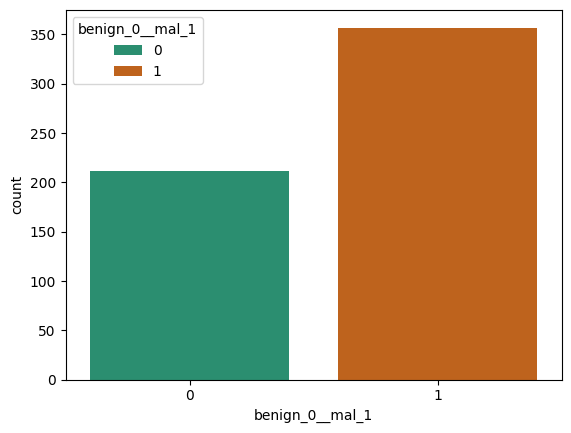

In [6]:
sns.countplot(data=df, x="benign_0__mal_1", palette="Dark2", hue='benign_0__mal_1')

<Axes: >

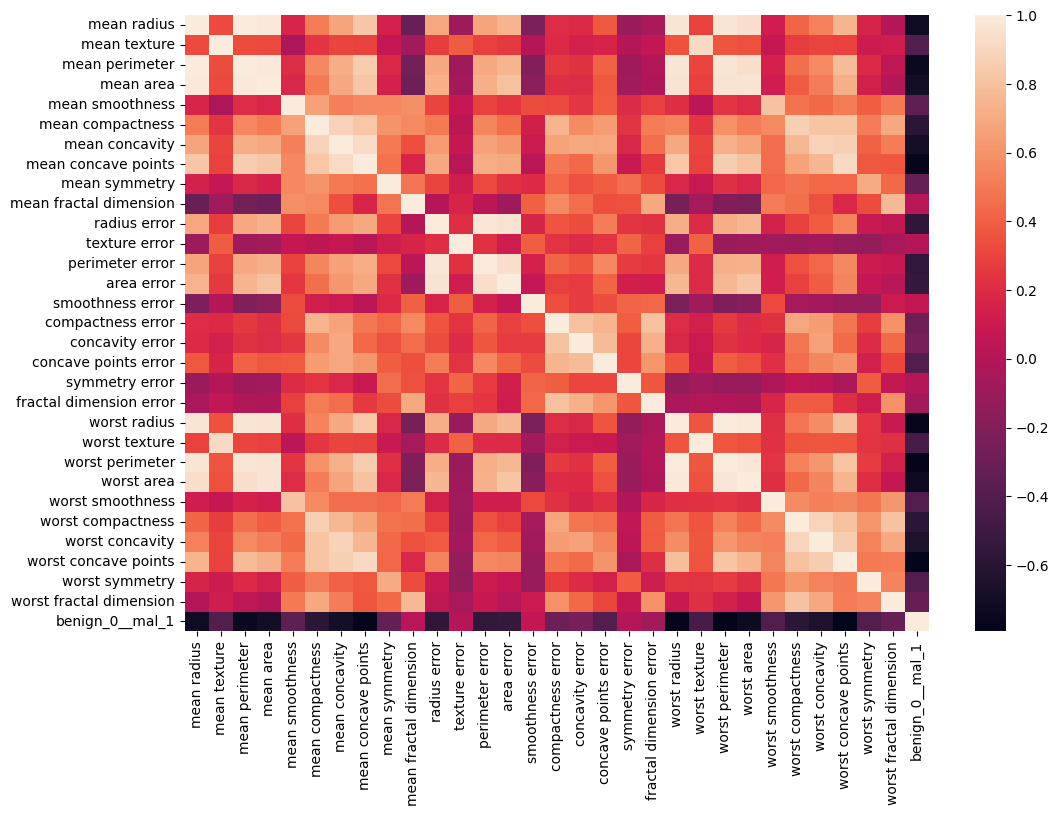

In [7]:
plt.figure(figsize=(12, 8))
sns.heatmap(data=df.corr())

In [8]:
df.corr()['benign_0__mal_1'].sort_values()

worst concave points      -0.793566
worst perimeter           -0.782914
mean concave points       -0.776614
worst radius              -0.776454
mean perimeter            -0.742636
worst area                -0.733825
mean radius               -0.730029
mean area                 -0.708984
mean concavity            -0.696360
worst concavity           -0.659610
mean compactness          -0.596534
worst compactness         -0.590998
radius error              -0.567134
perimeter error           -0.556141
area error                -0.548236
worst texture             -0.456903
worst smoothness          -0.421465
worst symmetry            -0.416294
mean texture              -0.415185
concave points error      -0.408042
mean smoothness           -0.358560
mean symmetry             -0.330499
worst fractal dimension   -0.323872
compactness error         -0.292999
concavity error           -0.253730
fractal dimension error   -0.077972
symmetry error             0.006522
texture error              0

<Axes: >

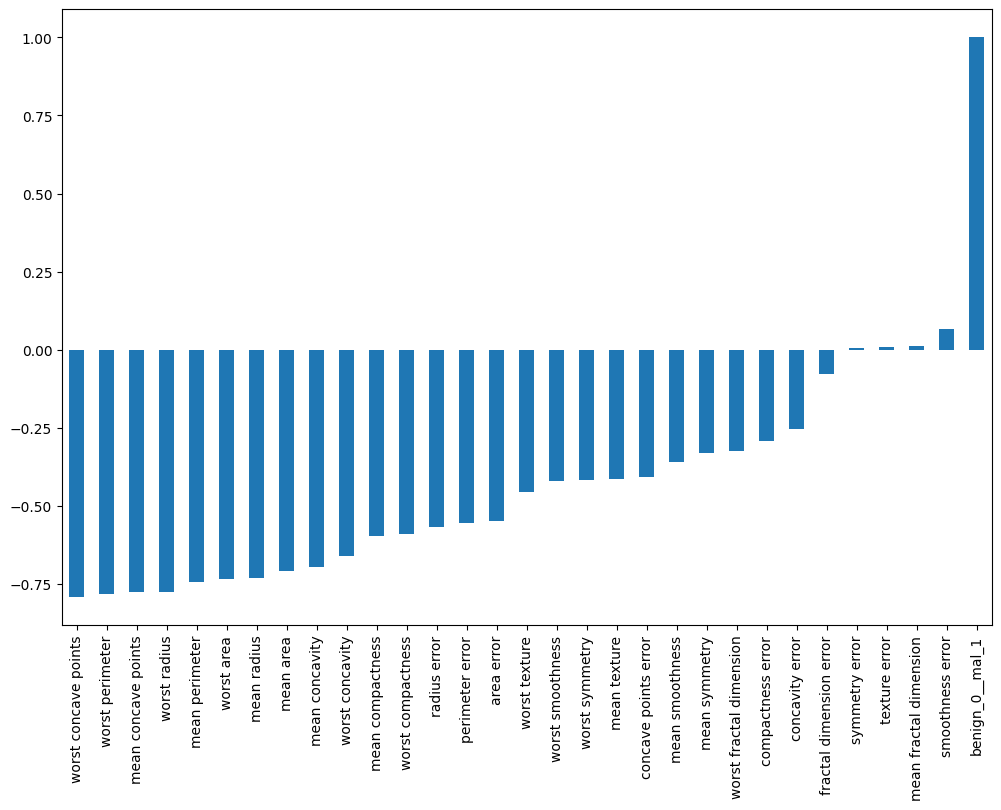

In [9]:
plt.figure(figsize=(12, 8))
df.corr()['benign_0__mal_1'].sort_values().plot(kind="bar")

<Axes: >

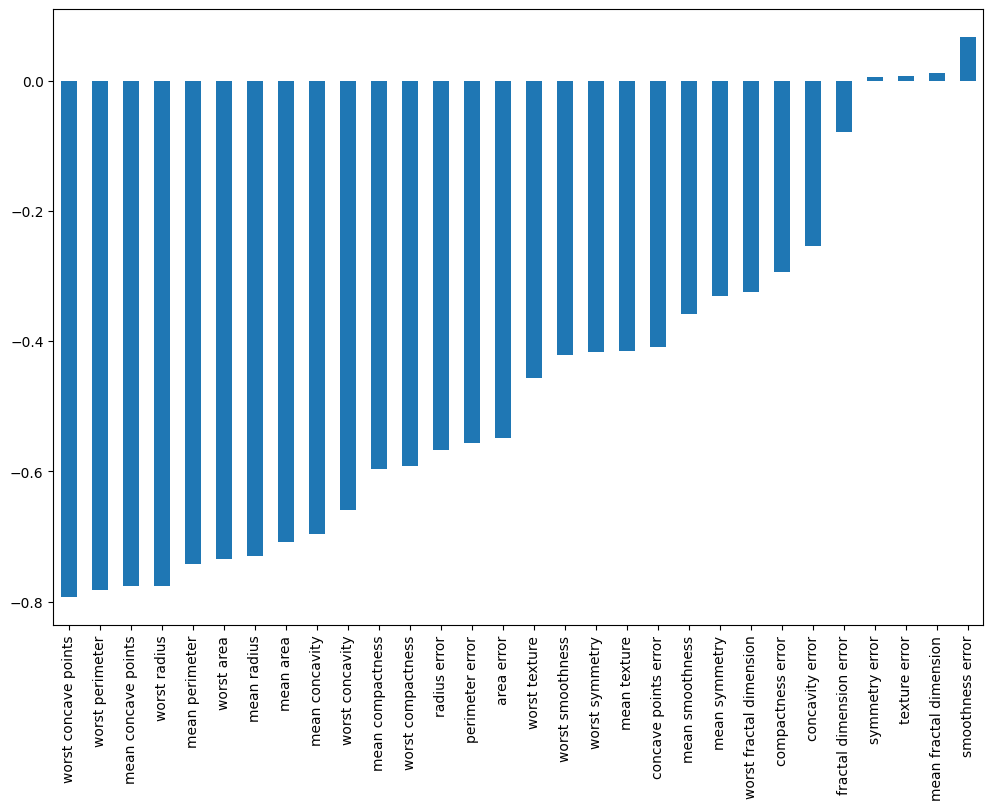

In [10]:
plt.figure(figsize=(12, 8))
df.corr()['benign_0__mal_1'][:-1].sort_values().plot(kind="bar")

# Train Test Split

In [11]:
from sklearn.model_selection import train_test_split

In [12]:
X = df.drop('benign_0__mal_1', axis=1).values
y = df['benign_0__mal_1'].values
X[:2], y[:2]

(array([[1.799e+01, 1.038e+01, 1.228e+02, 1.001e+03, 1.184e-01, 2.776e-01,
         3.001e-01, 1.471e-01, 2.419e-01, 7.871e-02, 1.095e+00, 9.053e-01,
         8.589e+00, 1.534e+02, 6.399e-03, 4.904e-02, 5.373e-02, 1.587e-02,
         3.003e-02, 6.193e-03, 2.538e+01, 1.733e+01, 1.846e+02, 2.019e+03,
         1.622e-01, 6.656e-01, 7.119e-01, 2.654e-01, 4.601e-01, 1.189e-01],
        [2.057e+01, 1.777e+01, 1.329e+02, 1.326e+03, 8.474e-02, 7.864e-02,
         8.690e-02, 7.017e-02, 1.812e-01, 5.667e-02, 5.435e-01, 7.339e-01,
         3.398e+00, 7.408e+01, 5.225e-03, 1.308e-02, 1.860e-02, 1.340e-02,
         1.389e-02, 3.532e-03, 2.499e+01, 2.341e+01, 1.588e+02, 1.956e+03,
         1.238e-01, 1.866e-01, 2.416e-01, 1.860e-01, 2.750e-01, 8.902e-02]]),
 array([0, 0]))

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=101)
X_train[:2], X_test[:-2]

(array([[1.317e+01, 1.822e+01, 8.428e+01, 5.373e+02, 7.466e-02, 5.994e-02,
         4.859e-02, 2.870e-02, 1.454e-01, 5.549e-02, 2.023e-01, 6.850e-01,
         1.236e+00, 1.689e+01, 5.969e-03, 1.493e-02, 1.564e-02, 8.463e-03,
         1.093e-02, 1.672e-03, 1.490e+01, 2.389e+01, 9.510e+01, 6.876e+02,
         1.282e-01, 1.965e-01, 1.876e-01, 1.045e-01, 2.235e-01, 6.925e-02],
        [1.262e+01, 1.715e+01, 8.062e+01, 4.929e+02, 8.583e-02, 5.430e-02,
         2.966e-02, 2.272e-02, 1.799e-01, 5.826e-02, 1.692e-01, 6.674e-01,
         1.116e+00, 1.332e+01, 3.888e-03, 8.539e-03, 1.256e-02, 6.888e-03,
         1.608e-02, 1.638e-03, 1.434e+01, 2.215e+01, 9.162e+01, 6.335e+02,
         1.225e-01, 1.517e-01, 1.887e-01, 9.851e-02, 3.270e-01, 7.330e-02]]),
 array([[1.236e+01, 1.854e+01, 7.901e+01, ..., 8.442e-02, 2.983e-01,
         7.185e-02],
        [1.404e+01, 1.598e+01, 8.978e+01, ..., 7.453e-02, 2.725e-01,
         7.234e-02],
        [1.291e+01, 1.633e+01, 8.253e+01, ..., 8.235e-02, 3.024e-0

In [14]:
X_train.shape, X_test.shape

((426, 30), (143, 30))

# Scaling Data

In [15]:
from sklearn.preprocessing import MinMaxScaler

In [16]:
scaler = MinMaxScaler()

In [17]:
scaler.fit(X_train)
X_train.shape, X_train[:2]

((426, 30),
 array([[1.317e+01, 1.822e+01, 8.428e+01, 5.373e+02, 7.466e-02, 5.994e-02,
         4.859e-02, 2.870e-02, 1.454e-01, 5.549e-02, 2.023e-01, 6.850e-01,
         1.236e+00, 1.689e+01, 5.969e-03, 1.493e-02, 1.564e-02, 8.463e-03,
         1.093e-02, 1.672e-03, 1.490e+01, 2.389e+01, 9.510e+01, 6.876e+02,
         1.282e-01, 1.965e-01, 1.876e-01, 1.045e-01, 2.235e-01, 6.925e-02],
        [1.262e+01, 1.715e+01, 8.062e+01, 4.929e+02, 8.583e-02, 5.430e-02,
         2.966e-02, 2.272e-02, 1.799e-01, 5.826e-02, 1.692e-01, 6.674e-01,
         1.116e+00, 1.332e+01, 3.888e-03, 8.539e-03, 1.256e-02, 6.888e-03,
         1.608e-02, 1.638e-03, 1.434e+01, 2.215e+01, 9.162e+01, 6.335e+02,
         1.225e-01, 1.517e-01, 1.887e-01, 9.851e-02, 3.270e-01, 7.330e-02]]))

In [18]:
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)
X_train[:2], X_test[:-2]

(array([[0.30280346, 0.28779168, 0.28292922, 0.16704136, 0.19888056,
         0.12440955, 0.11384724, 0.14264414, 0.1989899 , 0.11647009,
         0.03728187, 0.07124851, 0.02677025, 0.01806076, 0.19688208,
         0.09521735, 0.03949495, 0.16031445, 0.0428885 , 0.02685074,
         0.24795446, 0.31636461, 0.22257085, 0.12347621, 0.37660965,
         0.16416839, 0.14984026, 0.35910653, 0.13207175, 0.09320478],
        [0.27589412, 0.25160636, 0.25735448, 0.14820785, 0.29972014,
         0.10710999, 0.06949391, 0.11292247, 0.37323232, 0.17481045,
         0.02369123, 0.0673566 , 0.02006371, 0.01138751, 0.10061526,
         0.04721813, 0.03171717, 0.13047926, 0.11535431, 0.02567611,
         0.22803273, 0.26998934, 0.2052393 , 0.11017991, 0.3389685 ,
         0.1207032 , 0.15071885, 0.33852234, 0.33609304, 0.11976912]]),
 array([[0.26317335, 0.29861346, 0.2461044 , ..., 0.29010309, 0.27951902,
         0.11025843],
        [0.34536915, 0.21203923, 0.32136119, ..., 0.25611684, 0.22866154

## Creating the Model

    # For a binary classification problem
    model.compile(optimizer='rmsprop',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
                  
    

In [19]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation, Dropout

In [20]:
X_train.shape

(426, 30)

In [21]:
model = Sequential()

model.add(Dense(units=30, activation='relu'))
model.add(Dense(units=15, activation='relu'))

model.add(Dense(units=1, activation='sigmoid'))

model.compile(loss='binary_crossentropy', optimizer='adam')

## Training the Model 

### Example One: Choosing too many epochs and overfitting!

In [22]:
# https://stats.stackexchange.com/questions/164876/tradeoff-batch-size-vs-number-of-iterations-to-train-a-neural-network
# https://datascience.stackexchange.com/questions/18414/are-there-any-rules-for-choosing-the-size-of-a-mini-batch

model.fit(x=X_train, y=y_train, epochs=600, verbose=1, 
          validation_data=(X_test, y_test))

Epoch 1/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6611 - val_loss: 0.6259
Epoch 2/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.6129 - val_loss: 0.5885
Epoch 3/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.5815 - val_loss: 0.5446
Epoch 4/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.5356 - val_loss: 0.4983
Epoch 5/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 999us/step - loss: 0.4877 - val_loss: 0.4539
Epoch 6/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 1000us/step - loss: 0.4631 - val_loss: 0.4117
Epoch 7/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 974us/step - loss: 0.3977 - val_loss: 0.3663
Epoch 8/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 954us/step - loss: 0.3782 - val_loss: 0.3223
Epoch 9/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 951us/step - loss: 0.3331 - val_loss: 0.2871
Epoch 10/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 957us/step - loss: 0.2905 - val_loss: 0.2581
Epoch 11/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2710 - val_loss: 0.2324
Epoch 12/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/ste

In [23]:
model_loss = pd.DataFrame(model.history.history)
model_loss

,loss,val_loss
0,0.650491,0.625852
1,0.611958,0.588502
2,0.573097,0.544562
3,0.529388,0.498274
4,0.489192,0.453858
...,...,...
595,0.003885,0.242837
596,0.003998,0.230858
597,0.004125,0.224807
598,0.003531,0.243121


<Axes: >

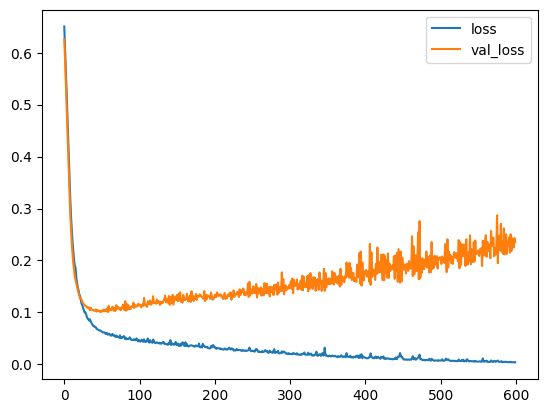

In [24]:
model_loss.plot()

## Example Two: Early Stopping

We obviously trained too much! Let's use early stopping to track the val_loss and stop training once it begins increasing too much!

In [25]:
model = Sequential()

model.add(Dense(units=30, activation='relu'))
model.add(Dense(units=15, activation='relu'))

model.add(Dense(units=1, activation='sigmoid'))

model.compile(loss='binary_crossentropy', optimizer='adam')

In [26]:
from tensorflow.keras.callbacks import EarlyStopping

Stop training when a monitored quantity has stopped improving.

    Arguments:
        monitor: Quantity to be monitored.
        min_delta: Minimum change in the monitored quantity
            to qualify as an improvement, i.e. an absolute
            change of less than min_delta, will count as no
            improvement.
        patience: Number of epochs with no improvement
            after which training will be stopped.
        verbose: verbosity mode.
        mode: One of `{"auto", "min", "max"}`. In `min` mode,
            training will stop when the quantity
            monitored has stopped decreasing; in `max`
            mode it will stop when the quantity
            monitored has stopped increasing; in `auto`
            mode, the direction is automatically inferred
            from the name of the monitored quantity.

In [27]:
e_stop = EarlyStopping(monitor='val_loss',
    patience=25,
    verbose=1,
    mode='min',)

In [28]:
model.fit(x=X_train, 
          y=y_train, 
          epochs=600,
          validation_data=(X_test, y_test), verbose=1,
          callbacks=[e_stop]
          )

Epoch 1/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.7091 - val_loss: 0.6641
Epoch 2/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.6619 - val_loss: 0.6268
Epoch 3/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.6266 - val_loss: 0.5861
Epoch 4/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.5745 - val_loss: 0.5354
Epoch 5/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.5257 - val_loss: 0.4819
Epoch 6/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4848 - val_loss: 0.4269
Epoch 7/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4224 - val_loss: 0.3763
Epoch 8/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3872 - val_loss: 0.3354
Epoch 9/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3456 - val_loss: 0.3006
Epoch 10/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3030 - val_loss: 0.2704
Epoch 11/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.2855 - val_loss: 0.2460
Epoch 12/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.2

<Axes: >

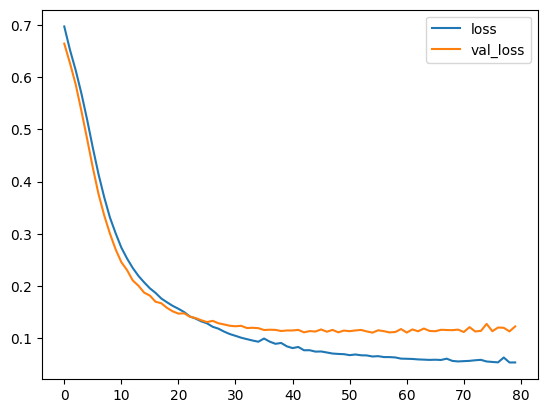

In [29]:
model_loss = pd.DataFrame(model.history.history)
model_loss.plot()